In [ ]:
%load_ext autoreload
%autoreload 2
from freq2clean import Freq2Clean
import torch
import sys

sys.path.append("..")
from src import *

Cupy Available= 1


## Tune loss coefficients by their influence on the learned alpha values

In [2]:
selected_trainings = [
    "20251112-1153-synthetic_deepcad_150",
    "20251112-1054-synthetic_deepcad_150",
    "20251112-1044-synthetic_deepcad_150",
    "20251112-1038-synthetic_deepcad_150",
    "20251112-1034-synthetic_deepcad_150",
]

In [10]:
trainings = sorted(Path("trainings").glob("*"), reverse=True)
alphas = {}
losses = {}
for training_dir in selected_trainings:
    training_dir = Path("trainings") / training_dir
    cfg = json.load(open(training_dir / "cfg.json"))
    metrics = pd.read_csv(training_dir / "metrics.csv")
    ckpt = sorted((training_dir / "pth").glob("*.pt"), key=lambda file: int(file.stem))[-1]
    model = Freq2Clean(shape=(cfg["patch_t"],), mode="dft1d")
    model.load_state_dict(torch.load(ckpt))
    suffx = f"$w_{{L1}}={cfg["w_l1"]:.2f} \\;,\\; w_{{L2}}={cfg["w_mse"]:.2f} \\;,\\; w_{{\\rho}}={cfg["w_corr"]:.2f} \\;,\\; w_{{Reg}}={cfg["w_reg"]:.2f}$"
    alphas[suffx] = pd.Series(model.mask.detach().numpy())
    losses[suffx] = metrics["loss"]

Text(0, 0.5, 'Convex combination coefficient ($\\alpha_\\omega$)')

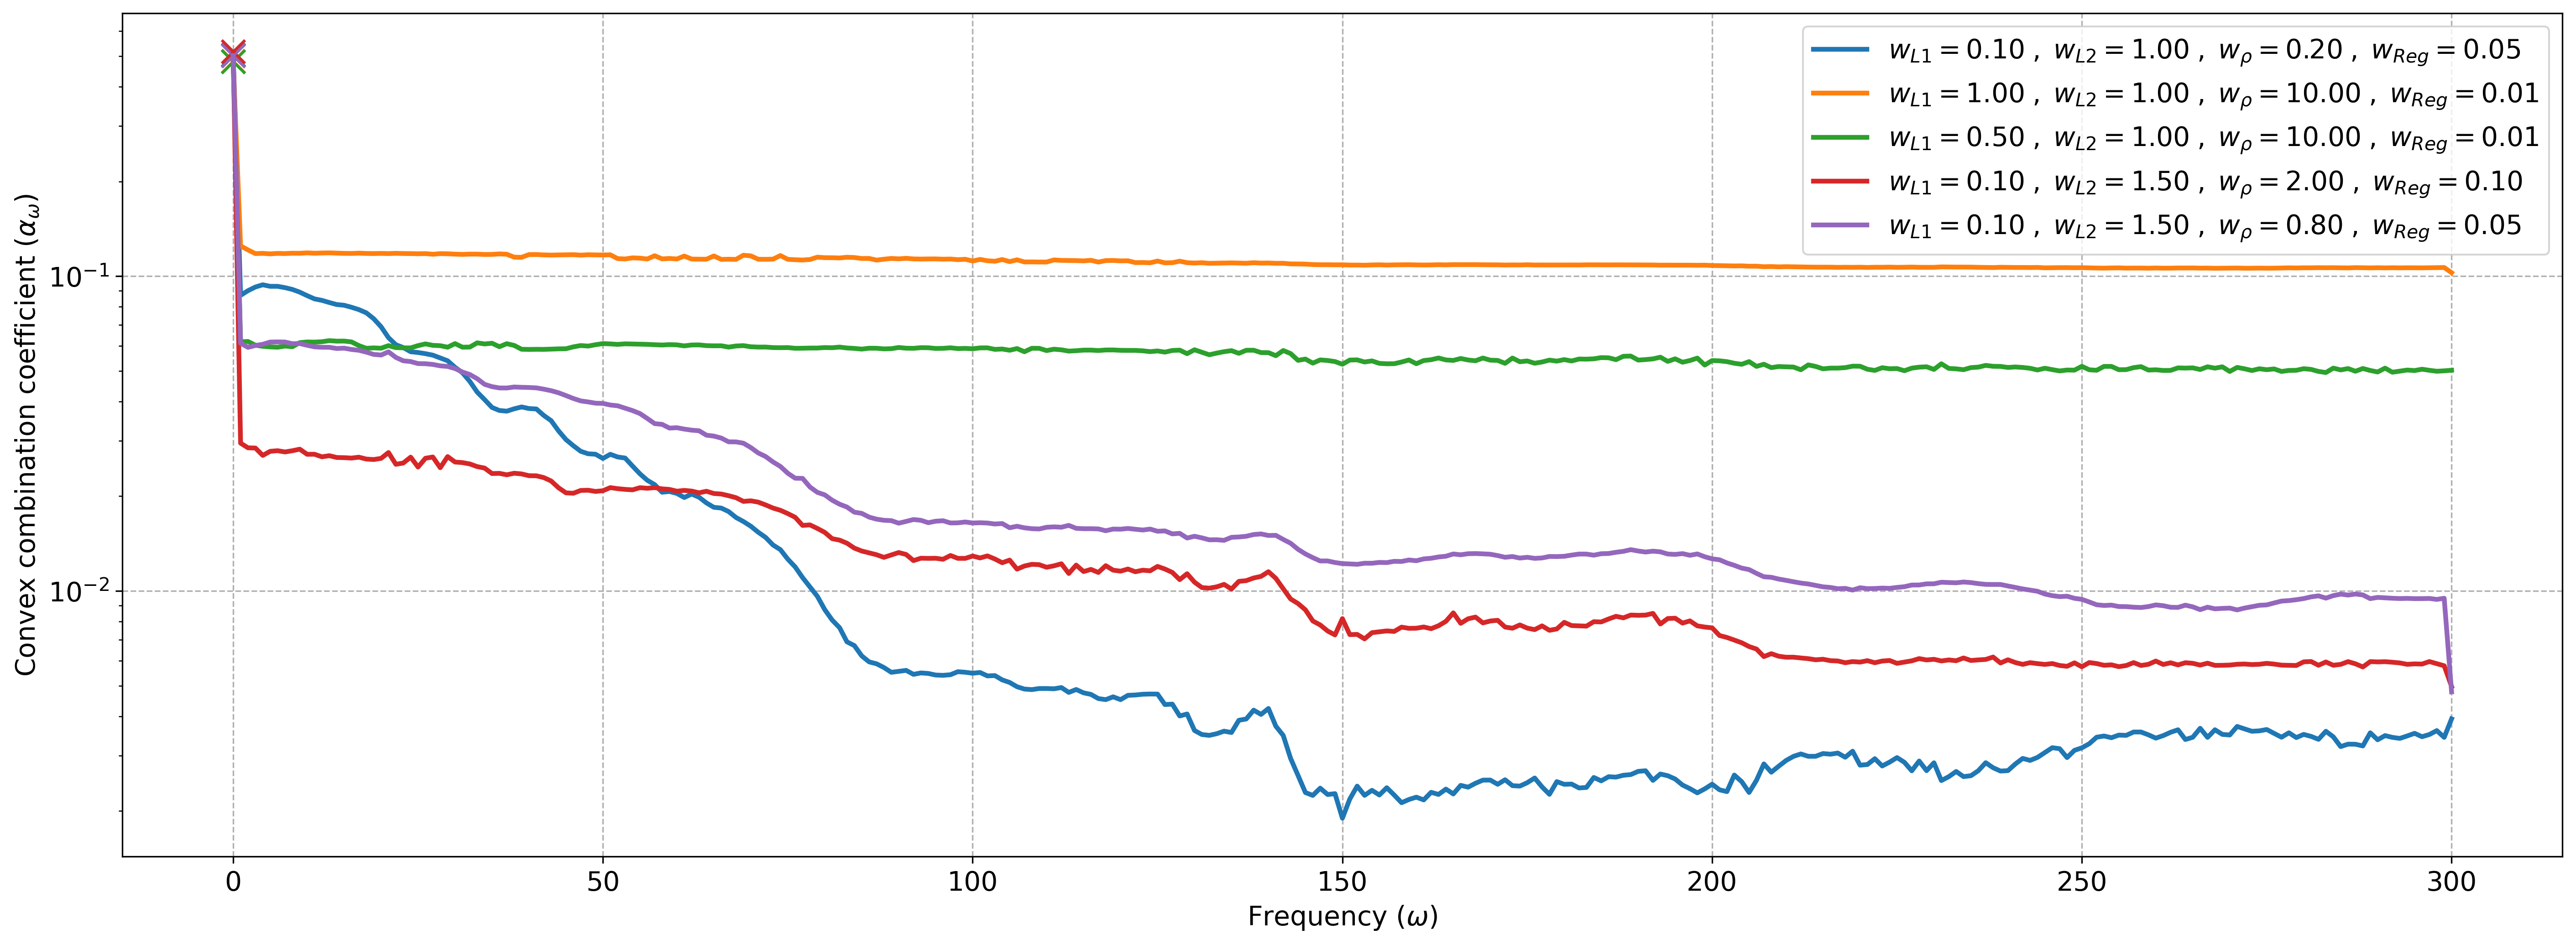

In [11]:
fig, ax = plt.subplots(figsize=(23, 8), dpi=300)
df = pd.DataFrame(alphas)
df.plot(ax=ax, linewidth=2.5)
for i, col in enumerate(df.columns):
    ax.scatter(0, df[col].iloc[0], s=150, marker="x")
plt.legend(prop={"family": "monospace"})
plt.yscale("log")
plt.xlabel("Frequency ($\\omega$)")
plt.ylabel("Convex combination coefficient ($\\alpha_\\omega$)")
# cprint(*[f"rand:{dir.stem}" for dir in trainings], sep="\n")

The $w_{l_1}= 1e^{-1},\quad w_{mse}= 1e^{-0},\quad w_{corr}= 2e^{-1},\quad w_{reg}= 5e^{-2}$ curve is the one we want.